# RAG, Embeddings и Векторные БД — Подробный разбор

Этот ноутбук объясняет теорию и показывает как всё работает под капотом.

## 1. Проблема: LLM не знает твои данные

**LLM (Large Language Model)** обучена на публичных данных интернета.

Она НЕ знает:
- Внутренние документы твоей компании
- Твою переписку
- Актуальные данные (обучение закончилось в прошлом)
- Специфичную информацию твоего домена

**Варианты решения:**

| Метод | Плюсы | Минусы |
|-------|-------|--------|
| **Fine-tuning** | Модель "запоминает" данные | Дорого, сложно, данные устаревают |
| **Промпт с контекстом** | Просто | Ограничение контекстного окна (4K-128K токенов) |
| **RAG** | Масштабируемо, данные актуальны | Нужна инфраструктура |

**RAG = Retrieval Augmented Generation** — находим релевантные документы и добавляем их в промпт.

## 2. Что такое Embedding?

**Embedding** — это представление текста в виде вектора (массива чисел).

### Зачем это нужно?

Компьютер не понимает текст напрямую. Ему нужны числа.

```
"Привет" → [0.12, -0.34, 0.56, 0.78, ...] (384 числа)
"Hello"  → [0.11, -0.32, 0.55, 0.77, ...] (похожий вектор!)
"Кошка"  → [0.89, 0.12, -0.45, 0.23, ...] (другой вектор)
```

### Ключевое свойство:
**Похожие по смыслу тексты → близкие векторы**

Это позволяет искать не по точному совпадению слов, а по смыслу!

In [1]:
# Загрузим модель для создания embeddings
from sentence_transformers import SentenceTransformer
import numpy as np

# Эта модель превращает текст в вектор из 384 чисел
# Модель обучена на миллионах пар "похожих" текстов
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print(f"Модель загружена")
print(f"Размерность вектора: {model.get_sentence_embedding_dimension()}")

C:\Users\Ruslan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/199 [00:00<00:00, 979.98it/s, Materializing param=embeddings.LayerNorm.bias]

Loading weights:   1%|          | 1/199 [00:00<00:00, 979.98it/s, Materializing param=embeddings.LayerNorm.bias]

Loading weights:   1%|          | 2/199 [00:00<00:00, 579.72it/s, Materializing param=embeddings.LayerNorm.weight]

...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 689.93it/s, Materializing param=pooler.dense.weight]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 689.93it/s, Materializing param=pooler.dense.weight]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 710.57it/s, Materializing param=pooler.dense.weight]


BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель загружена
Размерность вектора: 384


In [2]:
# Создадим embedding для одного слова
text = "Привет"
embedding = model.encode(text)

print(f"Текст: '{text}'")
print(f"Тип: {type(embedding)}")
print(f"Форма: {embedding.shape}")
print(f"\nПервые 10 чисел вектора:")
print(embedding[:10])
print(f"\nПоследние 10 чисел:")
print(embedding[-10:])

Текст: 'Привет'
Тип: <class 'numpy.ndarray'>
Форма: (384,)

Первые 10 чисел вектора:
[ 0.1415916   0.16500147  0.18058899  0.10149609 -0.17372327 -0.21749982
  0.47242144  0.1497917  -0.18404469  0.16898367]

Последние 10 чисел:
[ 0.16885936 -0.00788287  0.0048091  -0.05745991  0.00938481  0.2541831
  0.39882037  0.2001372  -0.16597411 -0.05126081]


### Что означают эти числа?

Каждое число — это "координата" в 384-мерном пространстве.

Представь упрощённо в 2D:
- Ось X = "формальность" (формальный → неформальный)
- Ось Y = "эмоциональность" (нейтральный → эмоциональный)

В реальности 384 таких "осей", каждая отвечает за какой-то аспект смысла.

**Мы не знаем точно что означает каждая ось** — модель сама выучила их во время обучения.

In [3]:
# Сравним embeddings похожих и разных текстов
texts = [
    "Привет, как дела?",           # 0
    "Здравствуй, как поживаешь?",  # 1 - похоже на 0
    "Hello, how are you?",          # 2 - то же на английском
    "Купить машину в Москве",       # 3 - совсем другое
    "Продажа автомобилей",          # 4 - похоже на 3
]

# Создаём embeddings для всех текстов
embeddings = model.encode(texts)

print(f"Создано {len(embeddings)} векторов")
print(f"Каждый вектор: {embeddings[0].shape}")

Создано 5 векторов
Каждый вектор: (384,)


### Как измерить похожесть векторов?

**Косинусное сходство (Cosine Similarity)**

Измеряет угол между двумя векторами:
- `1.0` = векторы смотрят в одном направлении (идентичны по смыслу)
- `0.0` = векторы перпендикулярны (не связаны)
- `-1.0` = векторы противоположны (антонимы)

```
cosine_similarity = (A · B) / (||A|| * ||B||)
```

Где:
- `A · B` — скалярное произведение
- `||A||` — длина вектора A

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

# Считаем косинусное сходство между ВСЕМИ парами
similarity_matrix = cosine_similarity(embeddings)

print("Матрица похожести (cosine similarity):")
print("="*60)

# Красивый вывод
for i, text_i in enumerate(texts):
    print(f"\n[{i}] '{text_i[:30]}...' похож на:")
    for j, text_j in enumerate(texts):
        if i != j:
            sim = similarity_matrix[i][j]
            bar = '█' * int(sim * 20)  # визуализация
            print(f"    [{j}] {sim:.3f} {bar}")

Матрица похожести (cosine similarity):

[0] 'Привет, как дела?...' похож на:
    [1] 0.965 ███████████████████
    [2] 0.934 ██████████████████
    [3] 0.124 ██
    [4] 0.174 ███

[1] 'Здравствуй, как поживаешь?...' похож на:
    [0] 0.965 ███████████████████
    [2] 0.974 ███████████████████
    [3] 0.094 █
    [4] 0.128 ██

[2] 'Hello, how are you?...' похож на:
    [0] 0.934 ██████████████████
    [1] 0.974 ███████████████████
    [3] 0.088 █
    [4] 0.118 ██

[3] 'Купить машину в Москве...' похож на:
    [0] 0.124 ██
    [1] 0.094 █
    [2] 0.088 █
    [4] 0.566 ███████████

[4] 'Продажа автомобилей...' похож на:
    [0] 0.174 ███
    [1] 0.128 ██
    [2] 0.118 ██
    [3] 0.566 ███████████


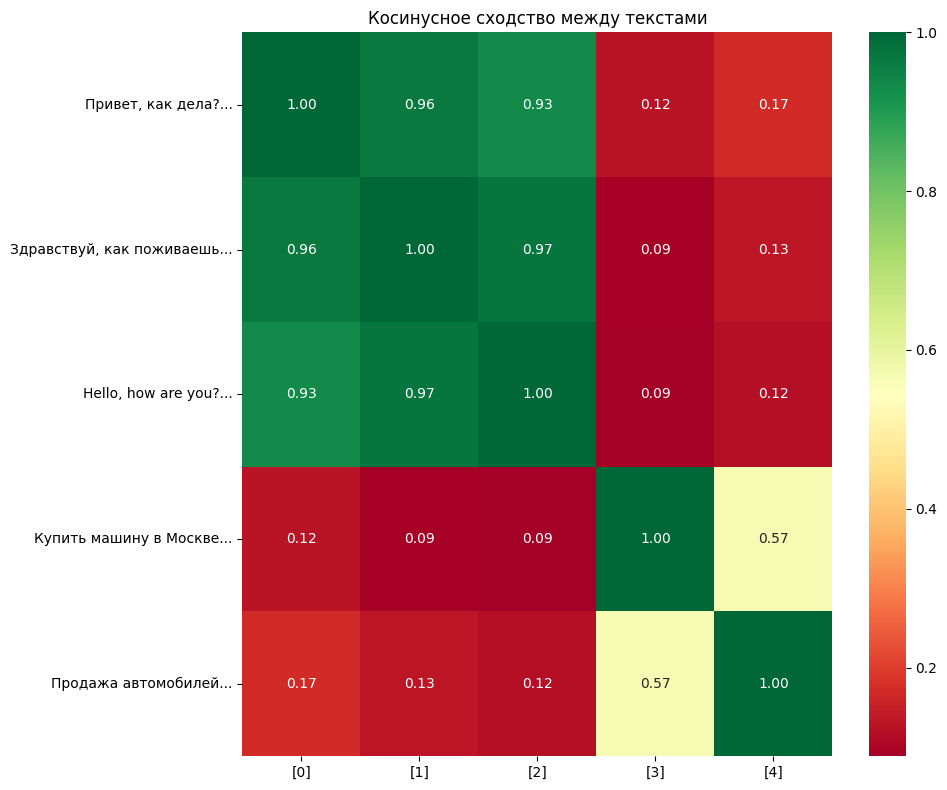


Легенда:
[0] Привет, как дела?
[1] Здравствуй, как поживаешь?
[2] Hello, how are you?
[3] Купить машину в Москве
[4] Продажа автомобилей


In [5]:
# Визуализация с помощью heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix, 
    annot=True,  # показать числа
    fmt='.2f',   # формат чисел
    cmap='RdYlGn',  # цветовая схема
    xticklabels=[f"[{i}]" for i in range(len(texts))],
    yticklabels=[t[:25] + "..." for t in texts]
)
plt.title('Косинусное сходство между текстами')
plt.tight_layout()
plt.show()

print("\nЛегенда:")
for i, t in enumerate(texts):
    print(f"[{i}] {t}")

### Что мы видим?

1. **"Привет, как дела?" ↔ "Здравствуй, как поживаешь?"** — высокое сходство (~0.8-0.9)
   - Разные слова, но одинаковый смысл!

2. **"Привет" ↔ "Hello, how are you?"** — тоже высокое сходство
   - Модель понимает разные языки!

3. **"Привет" ↔ "Купить машину"** — низкое сходство (~0.2-0.3)
   - Совершенно разные темы

4. **"Купить машину" ↔ "Продажа автомобилей"** — высокое сходство
   - Связанные темы, хотя слова разные

## 3. Векторная база данных

**Проблема:** У нас 1 миллион документов. Как быстро найти похожие?

**Наивный подход:**
```python
for doc in million_documents:
    similarity = cosine_similarity(query, doc)
```
Это O(n) — слишком медленно!

**Решение: Векторная БД** — специальные структуры данных для быстрого поиска похожих векторов.

### Как это работает (упрощённо):

1. **Индексирование:** Векторы группируются в "кластеры" по похожести
2. **Поиск:** Сначала находим ближайший кластер, потом ищем внутри него

Алгоритмы: HNSW, IVF, LSH и др.

### Популярные векторные БД:

| БД | Тип | Особенности |
|----|-----|-------------|
| **ChromaDB** | Embedded | Простая, для прототипов |
| **Pinecone** | Cloud | Масштабируемая, managed |
| **Weaviate** | Self-hosted/Cloud | GraphQL API, гибридный поиск |
| **Qdrant** | Self-hosted/Cloud | Rust, быстрая |
| **Milvus** | Self-hosted | Enterprise, очень масштабируемая |
| **pgvector** | PostgreSQL extension | Если уже есть PostgreSQL |

In [6]:
# Пример с ChromaDB
import chromadb

# Создаём клиент (в памяти)
# Для сохранения на диск: chromadb.PersistentClient(path="./chroma_db")
client = chromadb.Client()

# Создаём коллекцию (аналог таблицы)
collection = client.create_collection(
    name="demo",
    metadata={"description": "Демо коллекция"}
)

print(f"Коллекция '{collection.name}' создана")

Коллекция 'demo' создана


In [7]:
# Документы для индексации
documents = [
    "Python — интерпретируемый язык программирования с динамической типизацией.",
    "Java — компилируемый язык со статической типизацией и JVM.",
    "JavaScript используется для веб-разработки в браузере и Node.js.",
    "Кошки — домашние животные семейства кошачьих.",
    "Собаки — домашние животные, лучшие друзья человека.",
    "Machine Learning — подраздел AI для обучения на данных.",
    "Deep Learning использует нейронные сети с множеством слоёв.",
]

# Создаём embeddings
embeddings = model.encode(documents).tolist()

# Добавляем в ChromaDB
collection.add(
    ids=[f"doc_{i}" for i in range(len(documents))],  # уникальные ID
    documents=documents,                               # сами тексты
    embeddings=embeddings,                             # векторы
    metadatas=[{"index": i} for i in range(len(documents))]  # метаданные
)

print(f"Добавлено документов: {collection.count()}")

Добавлено документов: 7


In [8]:
# Поиск похожих документов
def search(query: str, n_results: int = 3):
    """Ищем документы похожие на запрос."""
    # 1. Превращаем запрос в вектор
    query_embedding = model.encode(query).tolist()
    
    # 2. Ищем ближайшие векторы в БД
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=n_results
    )
    
    return results

# Тест поиска
query = "Какой язык программирования выбрать для бэкенда?"
results = search(query)

print(f"Запрос: '{query}'")
print(f"\nНайденные документы:")
print("="*60)

for i, (doc, distance) in enumerate(zip(results['documents'][0], results['distances'][0])):
    # distance в ChromaDB — это L2 расстояние (меньше = ближе)
    similarity = 1 / (1 + distance)  # конвертируем в похожесть
    print(f"\n{i+1}. [similarity: {similarity:.3f}]")
    print(f"   {doc}")

Запрос: 'Какой язык программирования выбрать для бэкенда?'

Найденные документы:

1. [similarity: 0.057]
   Python — интерпретируемый язык программирования с динамической типизацией.

2. [similarity: 0.051]
   Java — компилируемый язык со статической типизацией и JVM.

3. [similarity: 0.043]
   Machine Learning — подраздел AI для обучения на данных.


In [9]:
# Ещё примеры поиска
queries = [
    "Расскажи про домашних питомцев",
    "Что такое нейросети?",
    "Как работает интерпретатор?"
]

for q in queries:
    print(f"\n{'='*60}")
    print(f"Q: {q}")
    results = search(q, n_results=2)
    for doc in results['documents'][0]:
        print(f"  → {doc}")


Q: Расскажи про домашних питомцев
  → Собаки — домашние животные, лучшие друзья человека.
  → Кошки — домашние животные семейства кошачьих.

Q: Что такое нейросети?
  → Deep Learning использует нейронные сети с множеством слоёв.
  → Machine Learning — подраздел AI для обучения на данных.

Q: Как работает интерпретатор?


  → Python — интерпретируемый язык программирования с динамической типизацией.
  → Java — компилируемый язык со статической типизацией и JVM.


## 4. RAG — собираем всё вместе

**RAG Pipeline:**

```
┌─────────────────────────────────────────────────────────────┐
│                     ИНДЕКСАЦИЯ (один раз)                   │
├─────────────────────────────────────────────────────────────┤
│  Документы → Chunking → Embeddings → Векторная БД          │
│     📄          ✂️           🔢            💾               │
└─────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────┐
│                     ЗАПРОС (каждый раз)                     │
├─────────────────────────────────────────────────────────────┤
│  Вопрос → Embedding → Поиск → Top-K docs → LLM → Ответ     │
│    ❓        🔢         🔍        📄          🤖     💬      │
└─────────────────────────────────────────────────────────────┘
```

### Промпт для LLM:

```
Система: Отвечай только на основе контекста.

Контекст:
[документ 1]
[документ 2]
[документ 3]

Вопрос: {вопрос пользователя}
```

In [10]:
from dotenv import load_dotenv
from openai import OpenAI
import os

load_dotenv("../../.env")

# DeepSeek клиент
llm = OpenAI(
    api_key=os.getenv('DEEPSEEK_API_KEY'),
    base_url="https://api.deepseek.com"
)

def rag_answer(question: str) -> str:
    """
    RAG: Поиск релевантных документов + генерация ответа.
    """
    # ШАГ 1: Поиск релевантных документов
    results = search(question, n_results=3)
    retrieved_docs = results['documents'][0]
    
    print(f"Найдено документов: {len(retrieved_docs)}")
    for i, doc in enumerate(retrieved_docs):
        print(f"  [{i+1}] {doc[:50]}...")
    
    # ШАГ 2: Формируем контекст
    context = "\n\n".join(retrieved_docs)
    
    # ШАГ 3: Создаём промпт
    system_prompt = """Ты помощник, который отвечает на вопросы.
Используй ТОЛЬКО информацию из контекста.
Если в контексте нет ответа — честно скажи, что не знаешь.
Отвечай кратко на русском языке."""
    
    user_prompt = f"""Контекст:
{context}

Вопрос: {question}

Ответ:"""
    
    # ШАГ 4: Генерация ответа через LLM
    response = llm.chat.completions.create(
        model="deepseek-chat",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        max_tokens=300,
        temperature=0.3  # низкая температура = более точные ответы
    )
    
    return response.choices[0].message.content

print("RAG функция готова")

RAG функция готова


In [11]:
# Тестируем RAG
question = "Чем Python отличается от Java?"

print(f"Вопрос: {question}")
print("="*60)
answer = rag_answer(question)
print(f"\nОтвет: {answer}")

Вопрос: Чем Python отличается от Java?
Найдено документов: 3
  [1] Python — интерпретируемый язык программирования с ...
  [2] Java — компилируемый язык со статической типизацие...
  [3] JavaScript используется для веб-разработки в брауз...



Ответ: Python — интерпретируемый язык с динамической типизацией, а Java — компилируемый язык со статической типизацией, который работает на JVM.


In [12]:
# Ещё примеры
questions = [
    "Что такое Deep Learning?",
    "Расскажи про кошек и собак",
    "Какой язык используется для веб-разработки?",
    "Кто президент России?"  # этого нет в контексте
]

for q in questions:
    print(f"\n{'='*60}")
    print(f"Q: {q}")
    print(f"A: {rag_answer(q)}")


Q: Что такое Deep Learning?
Найдено документов: 3
  [1] Deep Learning использует нейронные сети с множеств...
  [2] Machine Learning — подраздел AI для обучения на да...
  [3] Python — интерпретируемый язык программирования с ...


A: Deep Learning — это использование нейронных сетей с множеством слоёв.

Q: Расскажи про кошек и собак
Найдено документов: 3
  [1] Кошки — домашние животные семейства кошачьих....
  [2] Собаки — домашние животные, лучшие друзья человека...
  [3] Deep Learning использует нейронные сети с множеств...


A: Кошки — домашние животные семейства кошачьих. Собаки — домашние животные, лучшие друзья человека.

Q: Какой язык используется для веб-разработки?
Найдено документов: 3
  [1] JavaScript используется для веб-разработки в брауз...
  [2] Java — компилируемый язык со статической типизацие...
  [3] Python — интерпретируемый язык программирования с ...


A: JavaScript используется для веб-разработки.

Q: Кто президент России?
Найдено документов: 3
  [1] Собаки — домашние животные, лучшие друзья человека...
  [2] Machine Learning — подраздел AI для обучения на да...
  [3] JavaScript используется для веб-разработки в брауз...


A: Из предоставленного контекста эта информация не указана.


## 5. Проблемы и решения

### Проблема 1: Плохой поиск

**Симптом:** Нужный документ не находится.

**Причины:**
- Embedding модель не понимает домен/язык
- Слишком длинные документы (embedding "размывается")
- Запрос формулируется иначе, чем документ

**Решения:**
- Лучшая модель: `intfloat/multilingual-e5-large`, OpenAI embeddings
- Chunking: разбивать документы на части (500-1000 токенов)
- Гибридный поиск: vector + keyword (BM25)
- Reranking: после поиска переранжировать результаты

### Проблема 2: LLM игнорирует контекст

**Симптом:** LLM отвечает своими знаниями, а не из контекста.

**Решения:**
- Чёткие инструкции в system prompt
- Низкая temperature (0.1-0.3)
- Просить цитировать источник

### Проблема 3: Контекст не влезает

**Симптом:** Слишком много релевантных документов.

**Решения:**
- Summarization: сжимать документы перед добавлением
- Map-Reduce: обрабатывать документы по частям
- Модели с большим контекстом (Claude 200K, GPT-4 128K)

## 6. Сравнение с Java аналогиями

| Python/ML концепт | Java аналогия |
|-------------------|---------------|
| Embedding | `hashCode()`, но для смысла, а не равенства |
| Векторная БД | `HashMap`, но по "близости", а не точному ключу |
| Cosine Similarity | `Comparator`, но сравнивает "похожесть" |
| ChromaDB Collection | `Table` в JPA |
| RAG Pipeline | Паттерн Strategy + Template Method |
| Chunking | `String.split()` или токенизация |

### Пример на Java (псевдокод):

```java
// RAG на Java выглядел бы примерно так:

public class RAGService {
    private final EmbeddingModel embeddingModel;
    private final VectorStore vectorStore;
    private final LLMClient llmClient;
    
    public String answer(String question) {
        // 1. Создаём embedding для вопроса
        float[] queryVector = embeddingModel.encode(question);
        
        // 2. Ищем похожие документы
        List<Document> relevantDocs = vectorStore.search(queryVector, 3);
        
        // 3. Формируем контекст
        String context = relevantDocs.stream()
            .map(Document::getText)
            .collect(Collectors.joining("\n\n"));
        
        // 4. Генерируем ответ
        return llmClient.chat(buildPrompt(context, question));
    }
}
```

## Итоги

### Что такое RAG?
**Retrieval Augmented Generation** — добавляем релевантные документы в промпт LLM.

### Что такое Embedding?
**Вектор чисел**, представляющий смысл текста. Похожие тексты → близкие векторы.

### Что такое Векторная БД?
**База данных для быстрого поиска** похожих векторов (а не точного совпадения).

### RAG Pipeline:
1. **Индексация:** Документы → Chunks → Embeddings → VectorDB
2. **Запрос:** Question → Embedding → Search → Top-K → LLM → Answer

### Ключевые компоненты:
- **Embedding Model:** SentenceTransformers, OpenAI, Cohere
- **Vector DB:** ChromaDB, Pinecone, Weaviate, Qdrant
- **LLM:** DeepSeek, GPT-4, Claude, Llama